* Trabalho final FIS01085 - Ciência de Dados

Gabriel Souto e Pedro Griebler Reche

2025/2

In [8]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics, datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
import shap
import seaborn as sns
import statsmodels.formula.api as smf
from imblearn.over_sampling import SMOTE

# fetch dataset 
raisin = fetch_ucirepo(id=850) 
  
# data (as pandas dataframes) 
X = raisin.data.features 
y = raisin.data.targets 
  
# metadata 
print(raisin.metadata) 
  
# variable information 
print(raisin.variables) 

#Convert to Pandas DataFrame
df = raisin.data.original

print(df.head())



# Treatment of data


# Separating class from the features
target_column = 'Class'
features = list(df.columns)
features.remove(target_column) # Will be used for a list of all features

#Convert Kecimen to 0 and Besni to 1
df[target_column] = df[target_column].map({'Kecimen' : 0, 'Besni': 1})

{'uci_id': 850, 'name': 'Raisin', 'repository_url': 'https://archive.ics.uci.edu/dataset/850/raisin', 'data_url': 'https://archive.ics.uci.edu/static/public/850/data.csv', 'abstract': 'Images of the Kecimen and Besni raisin varieties were obtained with CVS. A total of 900 raisins were used, including 450 from both varieties, and 7 morphological features were extracted.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 900, 'num_features': 7, 'feature_types': ['Real', 'Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5660T', 'creators': ['İ̇lkay Çinar', 'Murat Koklu', 'Sakir Tasdemir'], 'intro_paper': {'ID': 261, 'type': 'NATIVE', 'title': 'Kuru Üzüm Tanelerinin Makine Görüşü ve Yapay Zeka Yöntemleri Kullanılarak Sınıflandırılması', 'authors': 'İ̇lkay Çinar

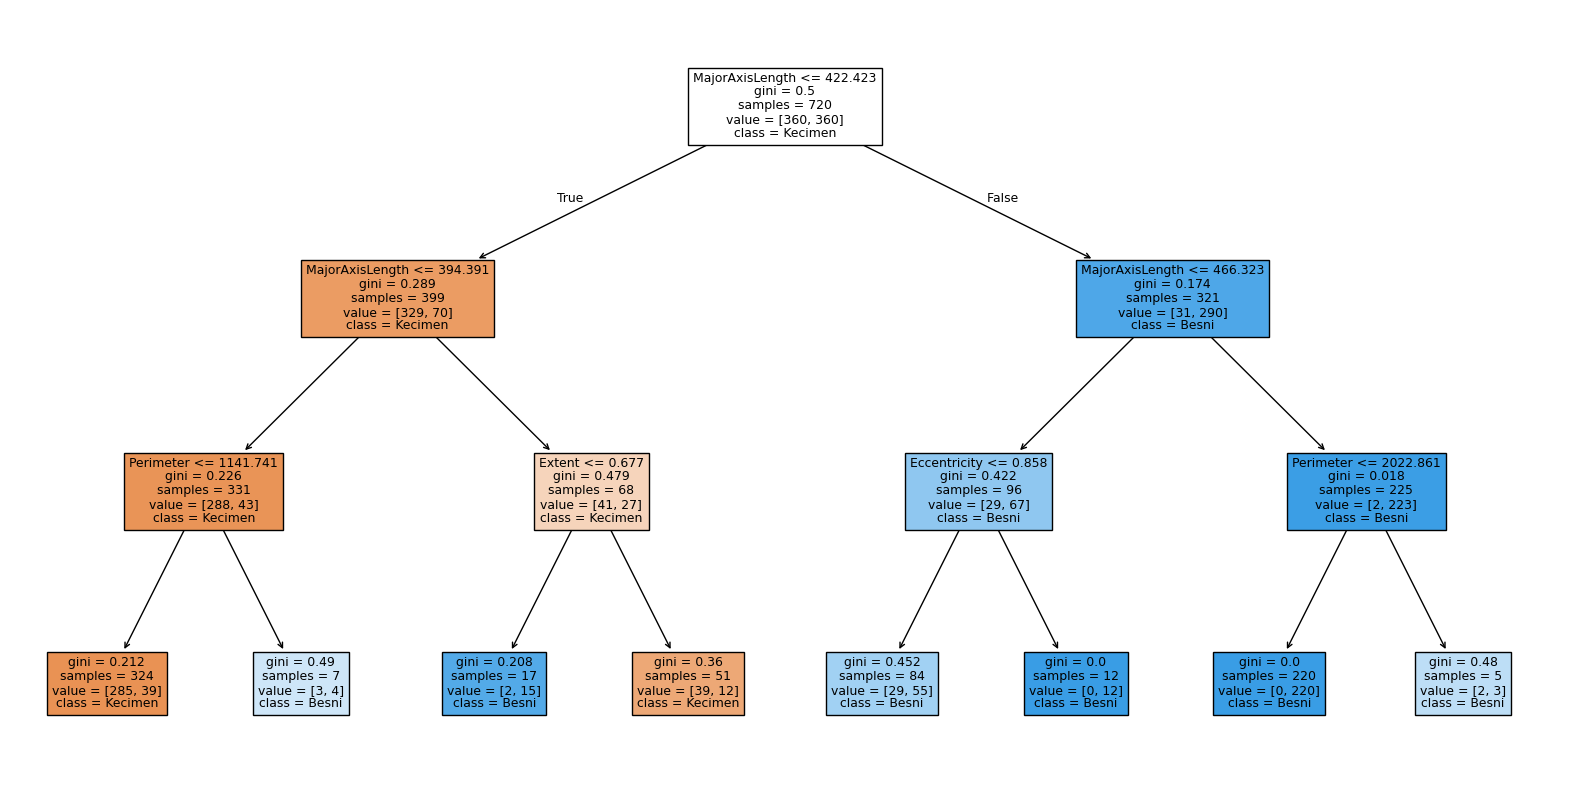

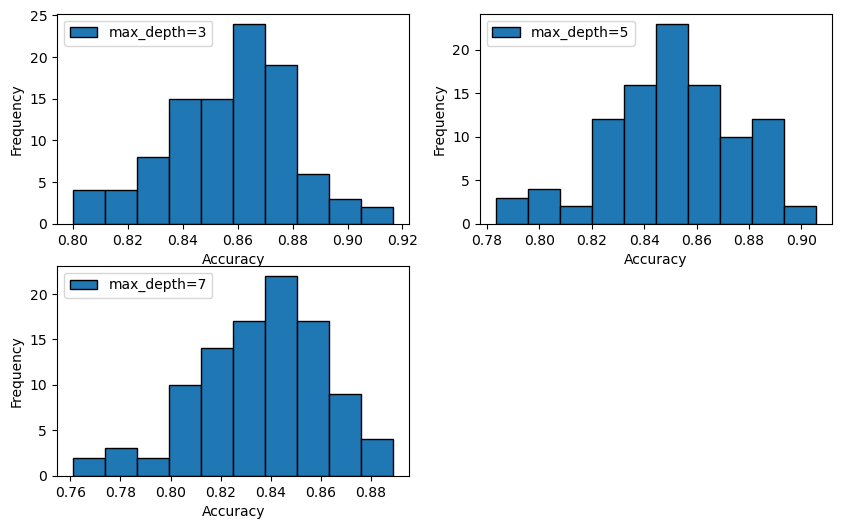

In [9]:
def evaluate_tree_model(max_depths, X, y, test_size, seeds):
    accuracies = np.zeros((len(max_depths), len(seeds)))

    # Loop para cada profundidade que você quer testar
    for i, depth in enumerate(max_depths):
        # O modelo é definido uma vez por profundidade com um estado aleatório fixo.
        # Isso garante que a única variável mudando no loop interno é a divisão dos dados.
        model = DecisionTreeClassifier(max_depth=depth, random_state=42) # Usando um valor fixo, como 42

        # Loop para cada semente aleatória para dividir os dados
        for j, seed in enumerate(seeds):
            # Divide os dados usando a semente da vez
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify = y)

            # Treina e avalia o modelo
            model.fit(X_train, y_train)
            accuracies[i, j] = model.score(X_test, y_test) # Armazena a acurácia

    return accuracies

def visualize_tree(X, test_size, seed, feature_names, class_names):

     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify = y)
     clf = DecisionTreeClassifier(max_depth=3, random_state=seed)
     clf.fit(X_train, y_train)

     plt.figure(figsize=(20,10))
     plot_tree(clf, filled=True, feature_names=feature_names, class_names=class_names)
     plt.savefig('decision_tree.png', dpi=500)
     plt.show()

# Realizar o scaling dos dados

X = df.drop(columns=[target_column])
y = df[target_column]

X_scaled = MinMaxScaler().fit_transform(X)

y_scaled = MinMaxScaler().fit_transform(y.values.reshape(-1, 1))

max_depths = [3, 5, 7]
seeds = np.random.randint(0, 1000, size=100)

test_size = 0.2

feature_names = features
class_names = ['Kecimen', 'Besni']

visualize_tree(X, test_size, seeds[0], feature_names, class_names)
accuracies = evaluate_tree_model(max_depths, X, y, test_size, seeds)

plt.figure(figsize=(10, 6))
plt.subplot(221)
plt.hist(accuracies[0, :], edgecolor='black', label='max_depth=3')

plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(222)
plt.hist(accuracies[1, :], label='max_depth=5', edgecolor='black')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(223)
plt.hist(accuracies[2, :], label='max_depth=7', edgecolor='black')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [10]:
# Definir os melhores parâmetros para Decision Trees obtidas

clf = DecisionTreeClassifier ()
grid_parameters = {
'criterion': [ 'gini' , 'entropy'] ,
'max_depth': [3 , 5 , 7 ] ,
'min_samples_leaf': [1 , 5] ,
}
grid_search = GridSearchCV ( estimator = clf , param_grid = grid_parameters , cv
=5)
grid_search.fit (X, y)
print ( " Melhores Parametros : " , grid_search.best_params_ )

 Melhores Parametros :  {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1}


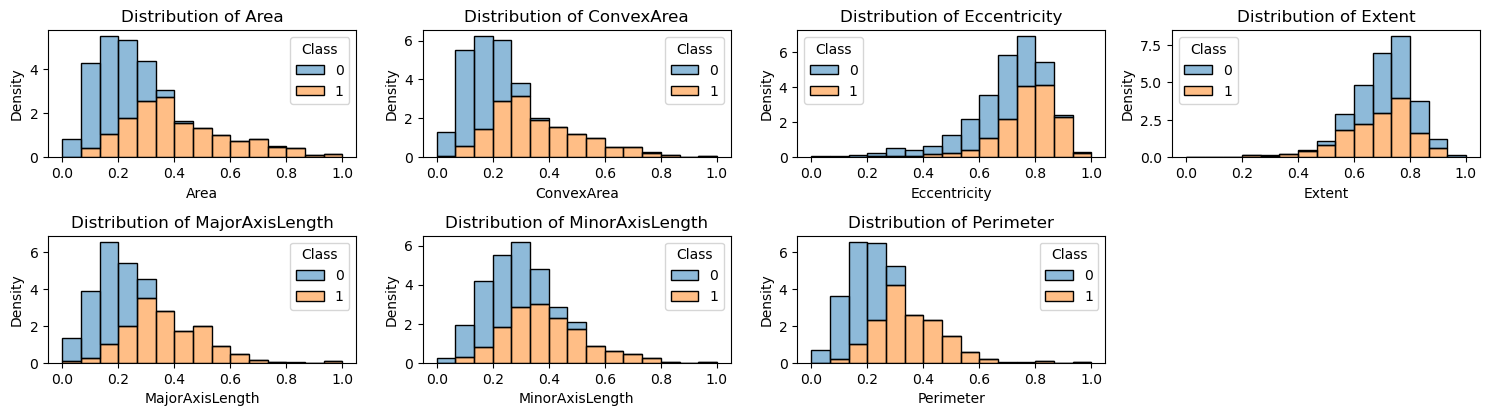

  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/450 [00:00<?, ?it/s]

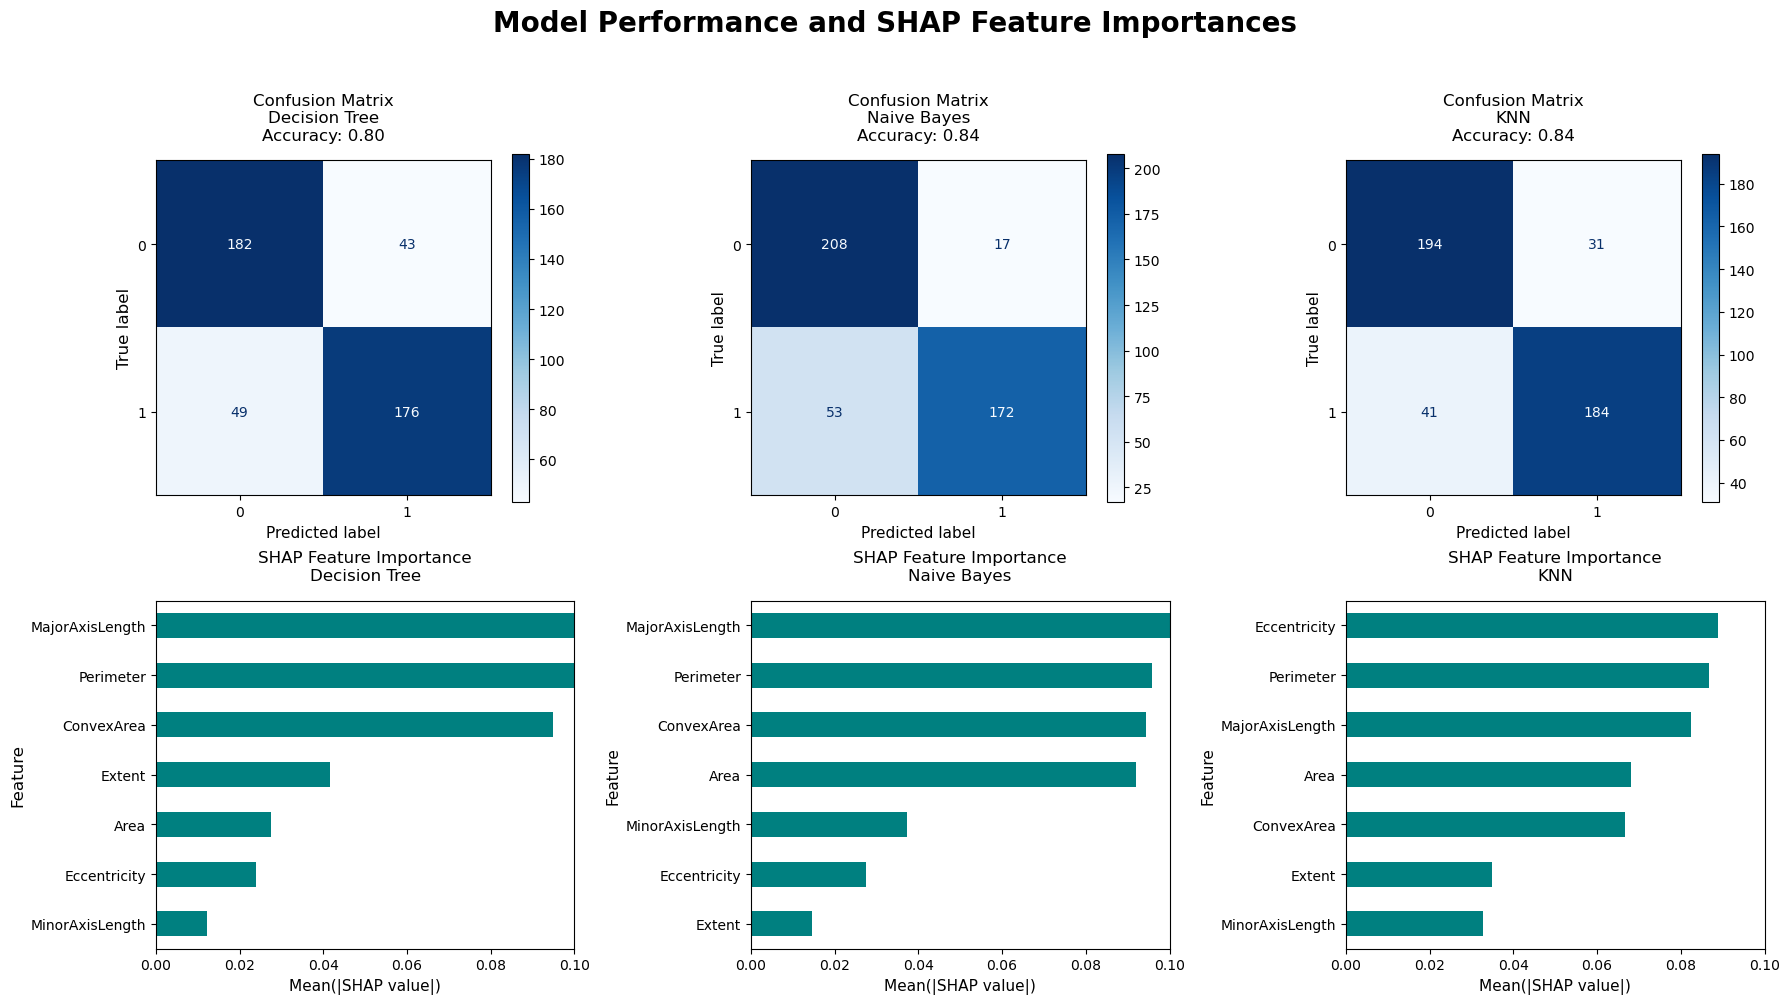

Accuracy and Metrics Table:


,Model,Metric,Score
0,Decision Tree,Accuracy,0.795556
1,Decision Tree,Precision,0.803653
2,Decision Tree,Recall,0.782222
3,Decision Tree,F1 Score,0.792793
4,Naive Bayes,Accuracy,0.844444
5,Naive Bayes,Precision,0.910053
6,Naive Bayes,Recall,0.764444
7,Naive Bayes,F1 Score,0.830918
8,KNN,Accuracy,0.840000
9,KNN,Precision,0.855814


<Figure size 1000x1000 with 0 Axes>

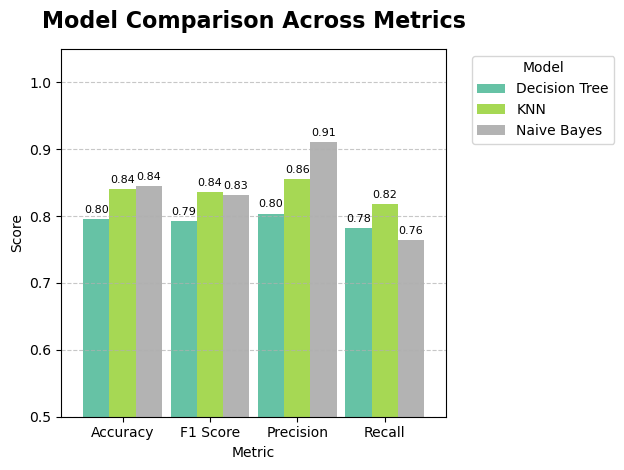

In [11]:
# Normalize all columns except target

columns_to_normalize = df.columns.difference([target_column])
df[columns_to_normalize] = (df[columns_to_normalize] - df[columns_to_normalize].min()) / (df[columns_to_normalize].max() - df[columns_to_normalize].min())

#Feature distributions splitting Kecimen and Besni raisin

plt.figure(figsize=(15, 10))
for i, column in enumerate(columns_to_normalize):
    plt.subplot(5, 4, i + 1)
    #plot as histogram
    sns.histplot(data=df, x=column, hue=target_column, multiple="stack", bins=15, alpha=0.5, stat = 'density', common_norm = False)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=3)
}
df.columns = df.columns.str.strip()

X = df.drop(columns=[target_column])
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify = y)
Accuracy_table = pd.DataFrame()
# Ensure order and types match
X_test = X_test[X_train.columns]
X_train = X_train.astype(float)
X_test = X_test.astype(float)

Accuracy_table = pd.DataFrame()
fig, axes = plt.subplots(2, len(models), figsize=(18, 10))
if len(models) == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure axes is 2D for consistency

for idx, (model_name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # SHAP KernelExplainer for all models
    background = shap.sample(X_train, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_test, nsamples=100)

    # Accuracy metrics table
    metrics_table = pd.DataFrame({
        'Model': model_name,
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Score': [
            metrics.accuracy_score(y_test, y_pred),
            metrics.precision_score(y_test, y_pred),
            metrics.recall_score(y_test, y_pred),
            metrics.f1_score(y_test, y_pred)
        ]
    })
    Accuracy_table = pd.concat([Accuracy_table, metrics_table], ignore_index=True)

    # Confusion matrix subplot
    metrics.ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[0, idx], colorbar=True, cmap='Blues'
    )
    axes[0, idx].set_title(f'Confusion Matrix\n{model_name}\nAccuracy: {metrics.accuracy_score(y_test, y_pred):.2f}', pad=15, fontsize=12)
    axes[0, idx].set_xlabel('Predicted label', fontsize=11)
    axes[0, idx].set_ylabel('True label', fontsize=11)

    # SHAP values subplot (feature importance)
    # For new SHAP: shap_values shape is (n_samples, n_features, n_outputs)
    if np.array(shap_values).shape == (X_test.shape[0], X_test.shape[1], 2):
        shap_importance = np.abs(shap_values[:, :, 1]).mean(axis=0)
        shap_df = pd.Series(shap_importance, index=X_test.columns).sort_values(ascending=True)
        shap_df.plot.barh(ax=axes[1, idx], color='teal')
        axes[1, idx].set_title(f'SHAP Feature Importance\n{model_name}', fontsize=12, pad=15)
        axes[1, idx].set_xlabel('Mean(|SHAP value|)', fontsize=11)
        axes[1, idx].set_ylabel('Feature', fontsize=11)
        axes[1, idx].set_xlim(0, 0.1)
    else:
        axes[1, idx].set_visible(False)
        print("Shape mismatch! Check your SHAP values and X_test.")

fig.suptitle("Model Performance and SHAP Feature Importances", fontsize=20, fontweight='bold', y=1.0)
axes[0, 0].set_ylabel('True label', fontsize=12)
axes[1, 0].set_ylabel('Feature', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Accuracy and Metrics Table:")
display(Accuracy_table)

# Pivot the table for plotting
metrics_pivot = Accuracy_table.pivot(index='Metric', columns='Model', values='Score')

plt.figure(figsize=(10, 10))
ax = metrics_pivot.plot(kind='bar', rot=0, width=0.9, colormap='Set2')
plt.title("Model Comparison Across Metrics", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score")
plt.ylim(0.5, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)

plt.show()

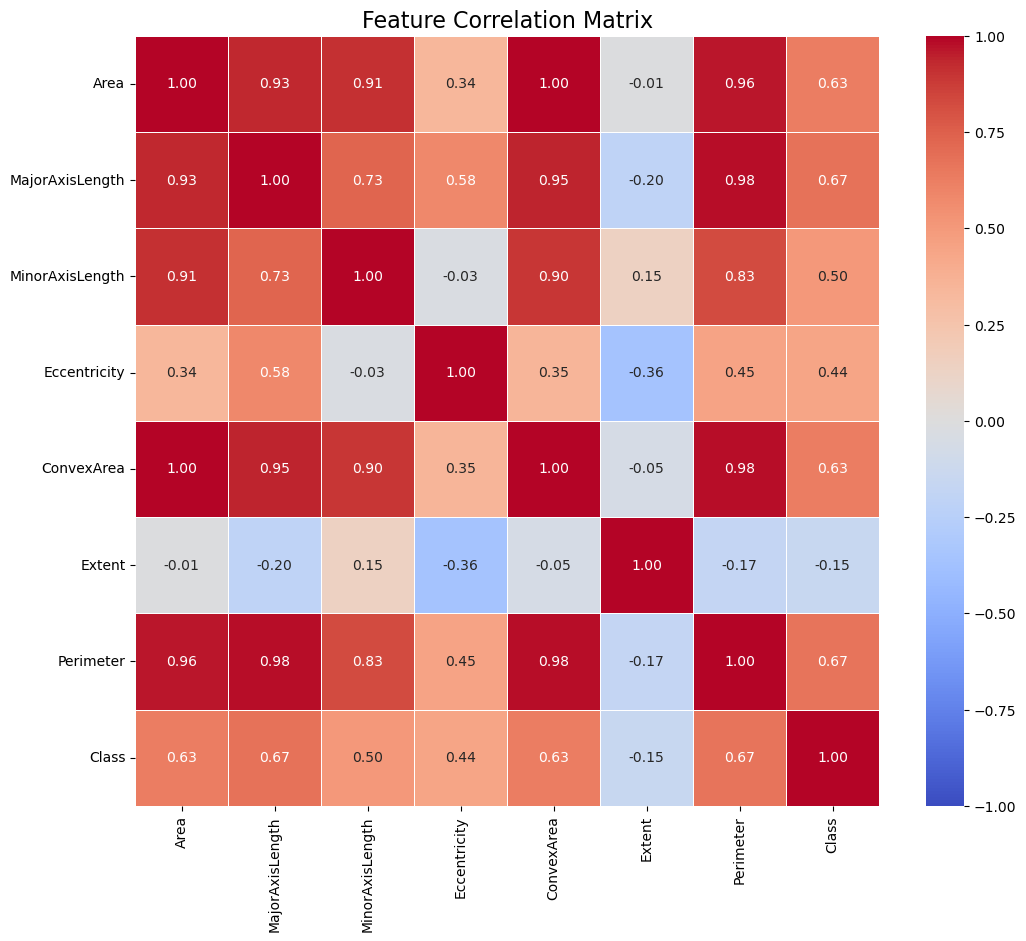

Top correlations with Target (Class):
Class              1.000000
MajorAxisLength    0.673194
Perimeter          0.665981
Area               0.625715
ConvexArea         0.625567
MinorAxisLength    0.503102
Eccentricity       0.438500
Extent            -0.154689
Name: Class, dtype: float64


In [24]:
#Criar mapa de correlação

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Correlation Matrix
# Ensure your target 'Class' is numeric (which you already did in your code)
corr_matrix = df.corr()

# 2. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,      # Show the numbers
    fmt=".2f",       # Format to 2 decimal places
    cmap='coolwarm', # Red for positive corr, Blue for negative
    vmin=-1, vmax=1, # Set scale limits
    linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# 3. Interpretation printout (Optional)
print("Top correlations with Target (Class):")
print(corr_matrix[target_column].sort_values(ascending=False))

Original data shape: (900, 8)
Imputing missing values in features...
Imputation complete.
X_train shape: (720, 7)
X_test shape: (180, 7)
y_train class distribution:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64
Applying SMOTE to training data...
Resampled y_train distribution:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64
Scaling data...
Training Linear SVM model...

--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        90
           1       0.96      0.79      0.87        90

    accuracy                           0.88       180
   macro avg       0.89      0.88      0.88       180
weighted avg       0.89      0.88      0.88       180

Generating feature importance plot for Linear SVM...


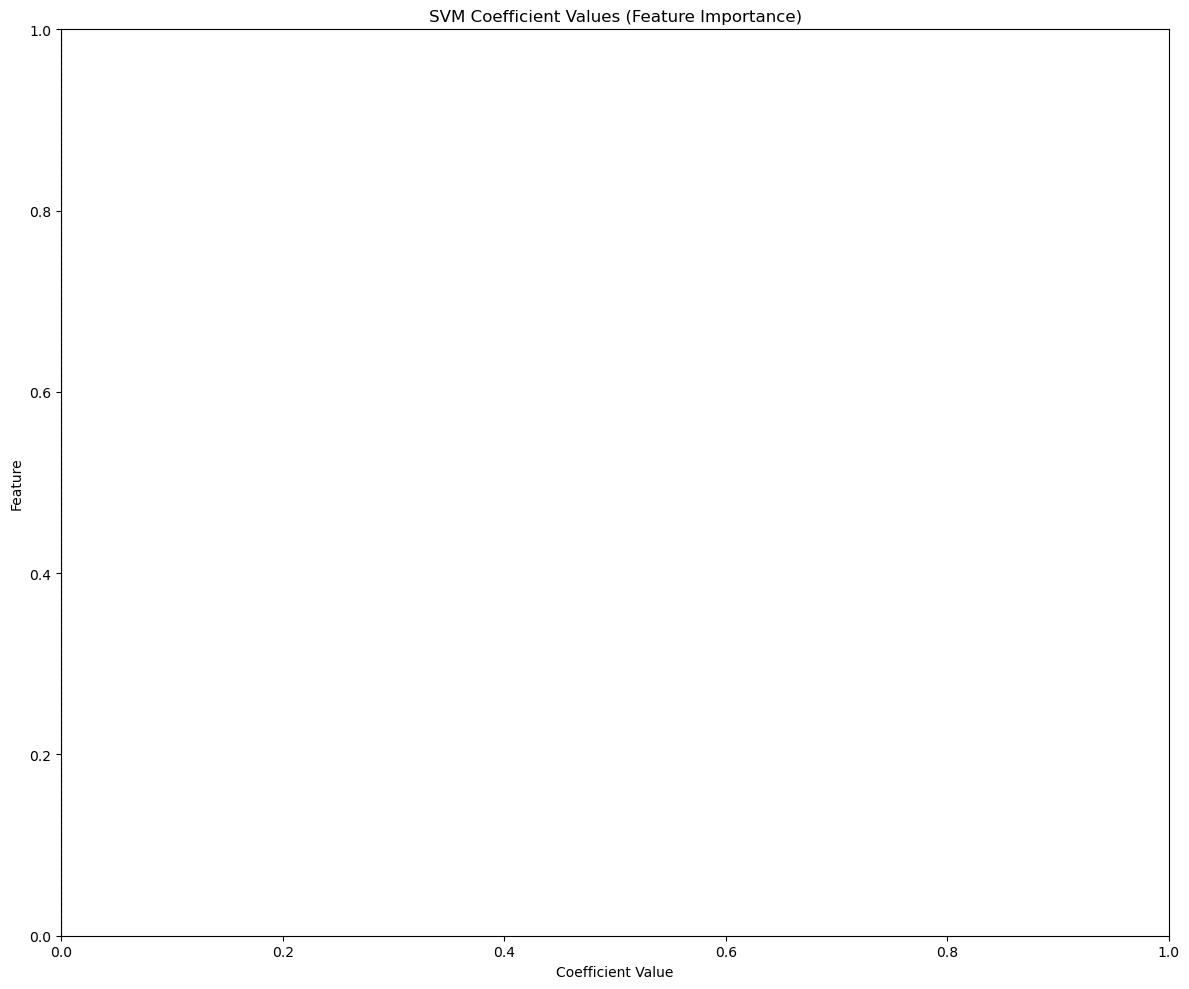

In [14]:
print(f"Original data shape: {df.shape}")

# Define X and y
X_svm = df.drop(columns=[target_column])
y_svm = df[target_column]

# Store feature names for later plotting
feature_names = X_svm.columns.tolist()

# SVM cannot handle any NaNs in the feature set - impute NaNs first
print("Imputing missing values in features...")
imputer = SimpleImputer(strategy='mean')
X_imputed_svm = imputer.fit_transform(X_svm)
print("Imputation complete.")


X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_imputed_svm, y_svm, stratify=y_svm, test_size=0.2, random_state=42) # Stratify argument to ensure class balance between train and test sets
print(f"X_train shape: {X_train_svm.shape}")
print(f"X_test shape: {X_test_svm.shape}")
print(f"y_train class distribution:\n{y_train_svm.value_counts(normalize=True)}")


# Apply SMOTE to the training data
print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_svm_resampled, y_train_svm_resampled = smote.fit_resample(X_train_svm, y_train_svm)
print(f"Resampled y_train distribution:\n{pd.Series(y_train_svm_resampled).value_counts(normalize=True)}")

# Scale the data
# We fit the scaler ONLY on the resampled training data - where there are values above 1.0
print("Scaling data...")
scaler = StandardScaler()
X_train_svm_scaled = scaler.fit_transform(X_train_svm_resampled)

# We use the same scaler to transform the test set
X_test_svm_scaled = scaler.transform(X_test_svm)

print("Training Linear SVM model...")
svm_model = SVC(kernel='poly', random_state=42) # Usado o mesmo kernel do paper 

# Train on the resampled and scaled data
svm_model.fit(X_train_svm_scaled, y_train_svm_resampled)

# Predict on the scaled test data
y_pred_svm = svm_model.predict(X_test_svm_scaled)

print("\n--- SVM Classification Report ---")
print(classification_report(y_test_svm, y_pred_svm))

# Visualizing Feature Importance
# X Dataset has 17 feautures (X.shape[1])
# The correct way to visualize a linear SVM's results is to plot its coefficients, which tell you the "importance" of each feature

print("Generating feature importance plot for Linear SVM...")

# Get the coefficients (w) - apenas para kernel linear
# coefficients = svm_model.coef_[0]

# importance_df = pd.DataFrame({
#     'feature': feature_names,
#     'coefficient': coefficients
# })

# Sort by the absolute value of the coefficient
# importance_df['abs_coefficient'] = importance_df['coefficient'].abs()
# importance_df = importance_df.sort_values(by='abs_coefficient', ascending=True)

# Create the plot
plt.figure(figsize=(12, 10))
#plt.barh(importance_df['feature'], importance_df['coefficient'])
plt.title('SVM Coefficient Values (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()

#plot_filename = 'svm_feature_importance.png'
#plt.savefig(plot_filename)
#print(f"Plot saved as '{plot_filename}'")

In [26]:


#Regressão logística

pd.set_option('display.float_format', '{:.4f}'.format)

try:
    target = target_column

    independent_vars = list(df.columns)

    covariates = list(df.columns)

    all_model_vars = [target] + independent_vars# + covariates


    df_subset = df[all_model_vars]

    initial_rows = len(df_subset)
    df_impute_base = df_subset.dropna(subset=[target])
    rows_dropped_for_target = initial_rows - len(df_impute_base)
    print(f"Dropped {rows_dropped_for_target} rows due to missing target ('{target}').")


    categorical_vars = list(df.columns)
    continuous_vars = [v for v in independent_vars + covariates if v not in categorical_vars]


    print("Imputing missing values...")


    df_model = df_impute_base.copy()


    cont_imputer = SimpleImputer(strategy='mean')
    cat_imputer = SimpleImputer(strategy='most_frequent') # Use mode for categories

    df_model[continuous_vars] = cont_imputer.fit_transform(df_model[continuous_vars])
    df_model[categorical_vars] = cat_imputer.fit_transform(df_model[categorical_vars])


    print(f"Original shape: {df.shape}")
    print(f"Shape after selecting model columns: {df_subset.shape}")
    print(f"Shape after dropping NaNs (final model data): {df_model.shape}")

    if df_model.shape[0] == 0:
        print("Error: All rows were dropped. Check if target variable has any non-NaN values.")
        raise ValueError("No data left to model.")

    print(f"Missing values left after imputation: {df_model.isna().sum().sum()}") # Should be 0


    # Build the R-style Formula for statsmodels
    formula_parts = continuous_vars
    formula_parts += [f"C({var})" for var in categorical_vars]
    formula = f"{target} ~ {' + '.join(formula_parts)}"

    print("--- Model Formula ---")
    print("Using formula:\n" + formula)

    # Run the Logistic Regression Model
    print("Fitting Logistic Regression model...")
    model = smf.logit(formula=formula, data=df_model)
    results = model.fit(method='powell')
    print("Model fitting successful.\_n")

    # Print the full statistical summary
    print("--- Model Summary (Coefficients & p-values) ---")
    print(results.summary())

    # Calculate and Display Odds Ratios
    print("\n--- Odds Ratios (Most Interpretable Result) ---")
    params = results.params
    conf = results.conf_int()
    conf['Odds Ratio'] = params
    conf.columns = ['CI 2.5%', 'CI 97.5%', 'Odds Ratio']

    odds_ratios_df = pd.DataFrame({
        'Odds Ratio': np.exp(params),
        'p-value': results.pvalues,
        'CI 2.5%': np.exp(conf['CI 2.5%']),
        'CI 97.5%': np.exp(conf['CI 97.5%'])
    })

    # Filter to show your core variables more clearly
    core_vars_in_model = []
    for var in independent_vars:
        if var in continuous_vars:
            core_vars_in_model.append(var)
        else:
            core_vars_in_model.extend([idx for idx in odds_ratios_df.index if idx.startswith(f"C({var})")])

    print("\n--- Key Findings (Odds Ratios for Core Independent Variables) ---")
    key_vars_df = odds_ratios_df.loc[odds_ratios_df.index.isin(core_vars_in_model)]
    print(key_vars_df)

    print("\n--- Key Findings (Odds Ratios for Covariates) ---")
    covariates_in_model = []
    for var in covariates:
        if var in continuous_vars:
            covariates_in_model.append(var)
        else:
            covariates_in_model.extend([idx for idx in odds_ratios_df.index if idx.startswith(f"C({var})")])

    covariates_df = odds_ratios_df.loc[odds_ratios_df.index.isin(covariates_in_model)]
    print(covariates_df)

except Exception as e:
    print(f"An error occurred: {e}")

Dropped 0 rows due to missing target ('Class').
Imputing missing values...
An error occurred: at least one array or dtype is required


Shape after dropping rows with missing target: (900, 8)
Data imputed and scaled.

--- Final DataFrame Head for Plotting ---
        PC1       PC2  Class
0  0.076994  0.453328      0
1 -0.475376 -0.445368      0
2  0.372109 -0.802008      0
3 -2.622445  0.302564      0
4 -0.962054  2.967763      0

--- PCA Loadings (Feature Contributions) ---
                      PC1       PC2
Area             0.448284  0.116100
MajorAxisLength  0.443240 -0.136587
MinorAxisLength  0.389381  0.374922
Eccentricity     0.202971 -0.610823
ConvexArea       0.450938  0.087616
Extent          -0.056368  0.667344
Perimeter        0.450824 -0.034172

--- Top Features by Influence on PC1 & PC2 ---
                      PC1       PC2  Magnitude
Extent          -0.056368  0.667344   0.669721
Eccentricity     0.202971 -0.610823   0.643663
MinorAxisLength  0.389381  0.374922   0.540541
MajorAxisLength  0.443240 -0.136587   0.463808
Area             0.448284  0.116100   0.463074
ConvexArea       0.450938  0.087616   

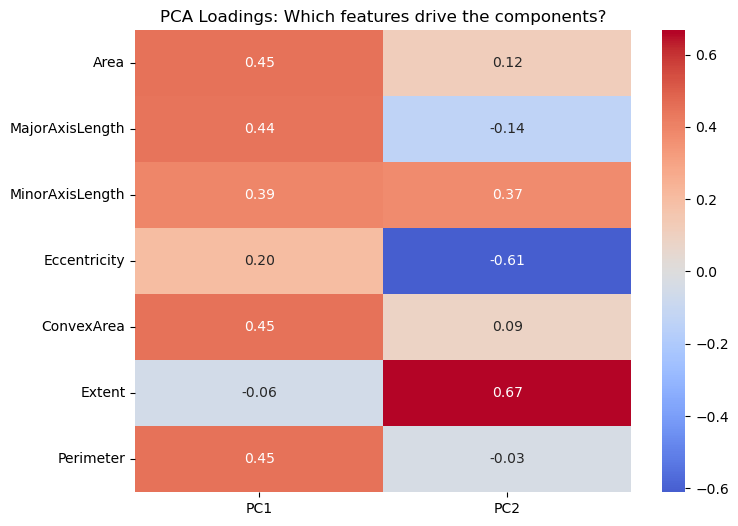


--- PCA Results ---
Explained Variance Ratio: [0.69032694 0.20759835]
Total Explained: 0.8979


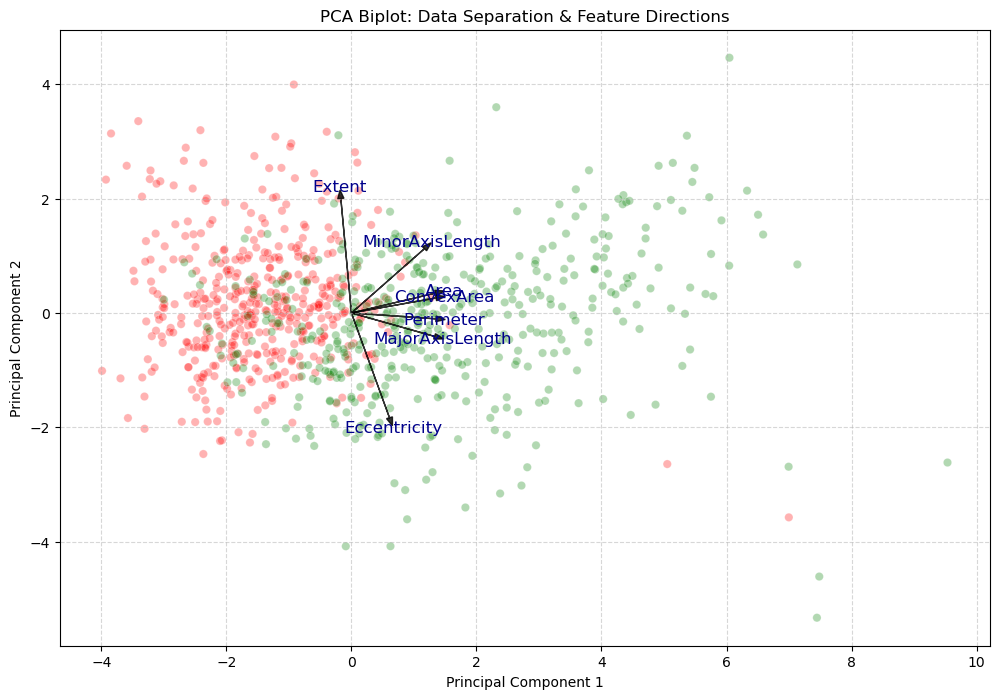

In [22]:
# 2a. Drop rows where the target is missing
# We can't plot data if we don't know its class (0 or 1)
df_clean = df.dropna(subset=[target_column])
print(f"Shape after dropping rows with missing target: {df_clean.shape}")

# 2b. Separate features (X) and target (y)
y = df_clean[target_column]
X = df_clean.drop(columns=[target_column])

# 2c. Impute missing values in features (X)
# PCA cannot handle any NaNs. We fill them with the column mean.
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# 2d. Scale features
# PCA is very sensitive to scale. This is a required step.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Data imputed and scaled.")

# --- 3. PCA ---

# # --- 5. Plotting (Corrected) ---


# plt.figure(figsize=(10, 7))
# fig = sns.scatterplot(
#     data=final_df,
#     x='PC1',
#     y='PC2',
#     hue= target_column,  # This colors the dots automatically
#     palette=['red', 'green'],              # Use your red/green colors
#     alpha=0.7
# )
# handles, labels = fig.get_legend_handles_labels()
# labels = list(labels)
# labels[0] = 'Kecimen'
# labels[1] = 'Besni'
# # 5b. Add titles and labels
# plt.title("Análise de Componentes Principais (PCA)", fontsize=16)
# plt.xlabel("Principal Component 1", fontsize=12)
# plt.ylabel("Principal Component 2", fontsize=12)
# plt.legend(title='Classificação', labels = labels, handles = handles)
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()

# # 5c. Save the plot
# plot_filename = 'pca_scatter_plot.png'
# plt.savefig(plot_filename)
# print(f"\nPlot saved as '{plot_filename}'")

# --- 3. PCA ---
pca = PCA(n_components=2)
raisin_componentes_principais = pca.fit_transform(X_scaled)


# --- 4. Create DataFrame ---

# 4a. Create the DataFrame with SIMPLE, string-based column names
raisin_df = pd.DataFrame(data = raisin_componentes_principais,
                      columns = ['PC1', 'PC2'])

# 4b. Combine PC data with target variable for plotting
# We must reset the index of 'y' to match the new 'raisin_df'
y_reset = y.reset_index(drop=True)
final_df = pd.concat([raisin_df, y_reset], axis=1)

print("\n--- Final DataFrame Head for Plotting ---")
print(final_df.head())


# --- NEW CODE START: Identify Feature Importance ---

# 1. Extract the loadings (coefficients)
# pca.components_ has shape [n_components, n_features]
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose to get features as rows
    columns=['PC1', 'PC2'],
    index=X.columns     # Use your original feature names
)

print("\n--- PCA Loadings (Feature Contributions) ---")
print(loadings)

# 2. Calculate overall importance (Magnitude)
# We can calculate the sum of squared loadings to see overall contribution to the first 2 PCs
loadings['Magnitude'] = (loadings['PC1']**2 + loadings['PC2']**2)**0.5
print("\n--- Top Features by Influence on PC1 & PC2 ---")
print(loadings.sort_values(by='Magnitude', ascending=False))

# 3. Visualize the Loadings with a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(loadings[['PC1', 'PC2']], annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("PCA Loadings: Which features drive the components?")
plt.show()

# 3b. Print variance
print("\n--- PCA Results ---")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Explained: {np.sum(pca.explained_variance_ratio_):.4f}")

# 4. (Optional) Biplot - Plotting feature vectors on your scatter plot
# This visualizes both the data points and the feature directions
plt.figure(figsize=(12, 8))

# Plot scatter (Points)
sns.scatterplot(
    data=final_df, x='PC1', y='PC2', hue=target_column, 
    palette=['red', 'green'], alpha=0.3, legend=False
)

# Plot feature vectors (Arrows)
for i, feature in enumerate(loadings.index):
    # Scale arrows up to match the scale of the scatter plot for visibility
    # You might need to adjust the scalar (e.g., * 3, * 5) depending on your data range
    scalar = 3 
    plt.arrow(0, 0, loadings.iloc[i, 0] * scalar, loadings.iloc[i, 1] * scalar, 
              color='black', alpha=0.8, head_width=0.1)
    plt.text(loadings.iloc[i, 0] * scalar * 1.1, loadings.iloc[i, 1] * scalar * 1.1, 
             feature, color='darkblue', ha='center', va='center', fontsize=12)

plt.title("PCA Biplot: Data Separation & Feature Directions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
